In [14]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.graph_objs as go
import plotly.offline as py
import pandas as pd

In [ ]:
df = pd.read_csv("../data/output_ecommerce_raw.csv")

# Data Cleaning

In [4]:
df['Description'] = df['Description'].fillna('Non_info')
df.dropna(inplace=True)

In [5]:
df['Invoice'] = df['Invoice'].astype(str)
df = df[~df["Invoice"].str.contains("C", na = False)]

In [6]:
df = df[df['Price'] != 0]
df = df[df['Quantity'] > 0]

In [7]:
df.drop_duplicates(inplace=True)

# Feature Engineering

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['date'] = df['InvoiceDate'].dt.strftime('%d/%m/%Y')
df['year'] = df['InvoiceDate'].dt.strftime('%Y')
df['month'] = df['InvoiceDate'].dt.strftime('%B')
df['day'] = df['InvoiceDate'].dt.strftime('%d')
df['hour'] = df['InvoiceDate'].dt.strftime('%H')
df['day_of_week'] = df['InvoiceDate'].dt.strftime('%A')

In [9]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

# EDA

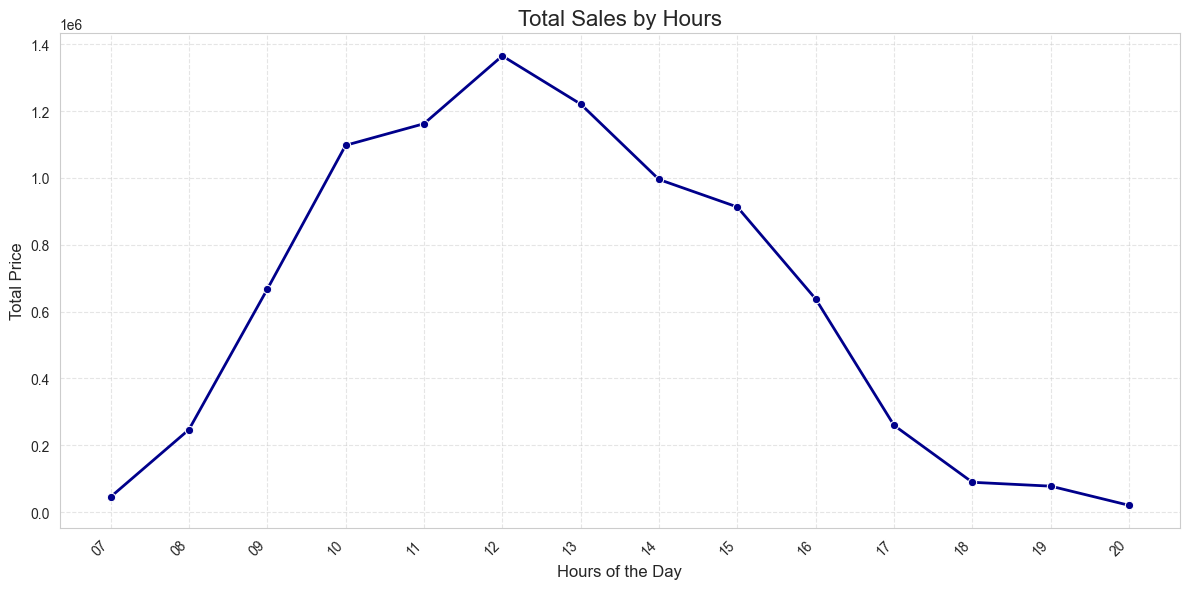

In [16]:
df_hours = df.groupby('hour').agg({'TotalPrice': 'sum'}).reset_index()

# Set the style
sns.set_style("whitegrid")

# Plot the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hours, x='hour', y='TotalPrice', marker='o', color='darkblue', linewidth=2)
plt.title('Total Sales by Hours', fontsize=16)
plt.xlabel('Hours of the Day', fontsize=12)
plt.ylabel('Total Price', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid lines
plt.tight_layout()
plt.show()

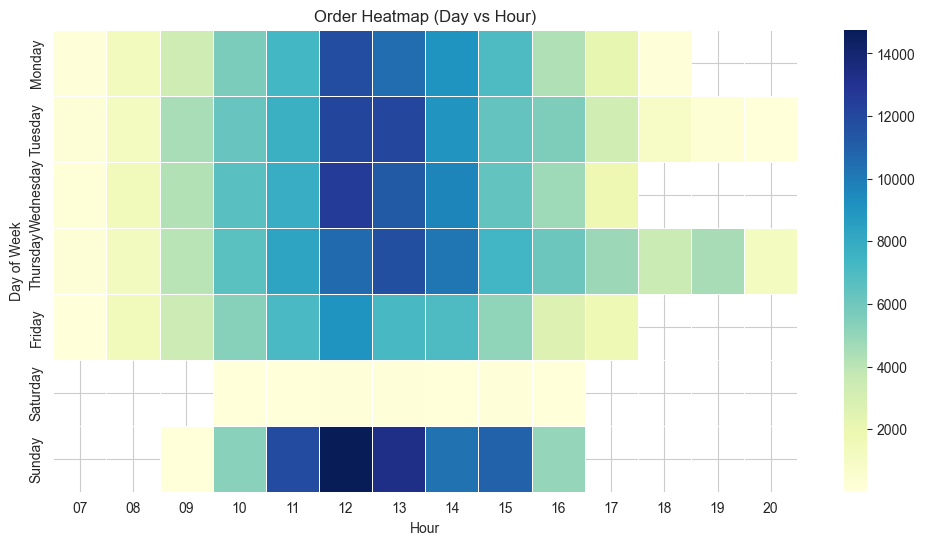

In [17]:
pivot = df.pivot_table(
    values='TotalPrice',
    index='day_of_week',
    columns='hour',
    aggfunc='count'
)

days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(days_order)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title('Order Heatmap (Day vs Hour)')
plt.xlabel('Hour')
plt.ylabel('Day of Week')

plt.show()

C:\Users\thinkbook\AppData\Local\Temp\ipykernel_468\3637334581.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pareto['Description'][:15], rotation=90)


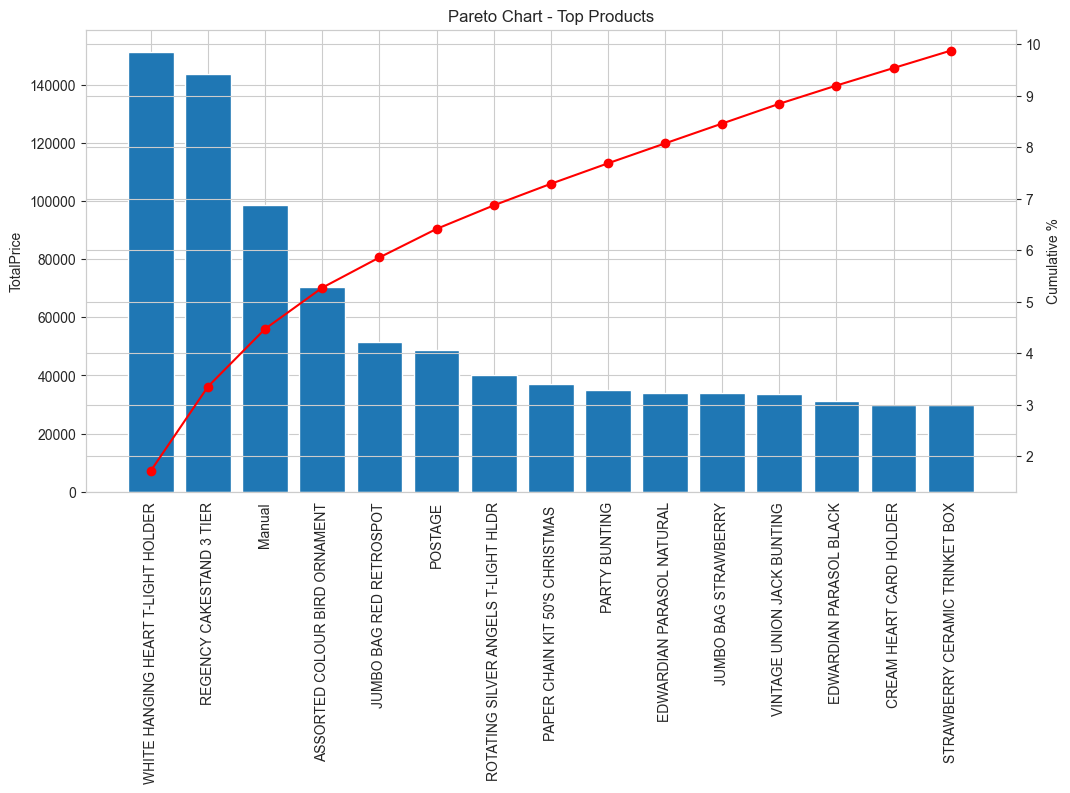

In [19]:
pareto = df.groupby('Description')['TotalPrice'].sum().reset_index()

# Sort giảm dần
pareto = pareto.sort_values(by='TotalPrice', ascending=False)

pareto['cum_sum'] = pareto['TotalPrice'].cumsum()
pareto['cum_pct'] = pareto['cum_sum'] / pareto['TotalPrice'].sum() * 100



fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart (Revenue)
ax1.bar(pareto['Description'][:15], pareto['TotalPrice'][:15])
ax1.set_ylabel('TotalPrice')
ax1.set_xticklabels(pareto['Description'][:15], rotation=90)

# Line chart (% tích luỹ)
ax2 = ax1.twinx()
ax2.plot(pareto['Description'][:15], pareto['cum_pct'][:15], color='red', marker='o')
ax2.set_ylabel('Cumulative %')

plt.title('Pareto Chart - Top Products')
plt.show()

In [20]:
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']

rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm['segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str)



In [21]:
seg_map = {
r'[1-2][1-2]': 'hibernating',
r'[1-2][3-4]': 'at_risk',
r'[1-2]5': 'cant_loose',
r'3[1-2]': 'about_to_sleep',
r'33': 'need_attention',
r'[3-4][4-5]': 'loyal_customers',
r'41': 'promising',
r'51': 'new_customers',
r'[4-5][2-3]': 'potential_loyalists',
r'5[4-5]': 'champions'
    }

# Map RFM segments to corresponding customer segments using predefined seg_map
rfm['segment'] = rfm['segment'].replace(seg_map, regex=True)

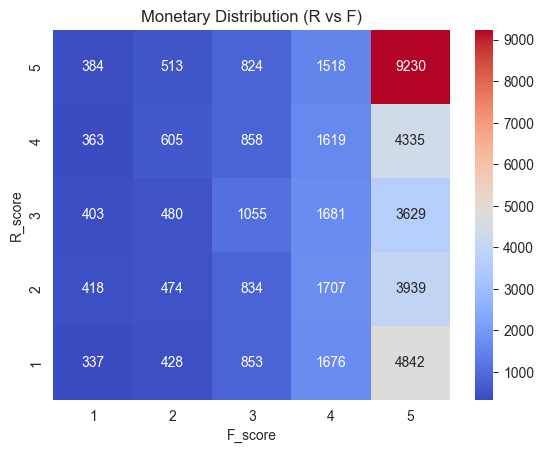

In [22]:
# Pivot
pivot_rf = rfm.pivot_table(
    index='R_score',
    columns='F_score',
    values='monetary',
    aggfunc='mean'
)

# Plot
sns.heatmap(pivot_rf, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Monetary Distribution (R vs F)")
plt.show()